<a href="https://colab.research.google.com/github/rangabhashini187-hub/neuroExercise/blob/main/SignalDataPreprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install MNE if it is not already available in Google Colab
!pip -q install mne

# Numerical operations
import numpy as np

# Data tables and statistics
import pandas as pd

# Plotting
import matplotlib.pyplot as plt

# EEG processing
import mne

# Signal-processing functions
from scipy import signal

# Deep learning
import tensorflow as tf
from tensorflow.keras import layers, Model

# Machine-learning utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("Libraries imported successfully.")
print("MNE version:", mne.__version__)
print("TensorFlow version:", tf.__version__)

import mne

Libraries imported successfully.
MNE version: 1.13.0
TensorFlow version: 2.20.0


In [ ]:
import os

# Path of the sample EEG file uploaded to Colab
file_path = "/content/S001R04.edf"

# IMPORTANT: Please upload the file 'S001R04.edf' to your Colab environment
# (e.g., by dragging and dropping it into the files pane on the left).
# The FileNotFoundError indicates the file was not found.

# Only attempt to load the file if it exists.
if os.path.exists(file_path):
    # Load the EDF file.
    # preload=True loads the signal into memory so that we can process it.
    raw = mne.io.read_raw_edf(
        file_path,
        preload=True,
        verbose=False
    )

    print(raw)
else:
    print(f"Error: The file {file_path} does not exist. Please upload it to Colab.")
    raw = None # Ensure 'raw' is defined even if file is missing

<RawEDF | S001R04.edf, 64 x 7840 (49.0 s), ~3.9 MiB, data loaded>


/tmp/ipykernel_754/1576613925.py:14: RuntimeWarning: Number of records from the header does not match the file size (perhaps the recording was not stopped before exiting). Inferring from the file size.
  raw = mne.io.read_raw_edf(
/tmp/ipykernel_754/1576613925.py:14: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(


In [ ]:
# Number of EEG channels
n_channels = len(raw.ch_names)

# Sampling frequency
sampling_frequency = raw.info["sfreq"]

# Number of samples
n_samples = raw.n_times

# Recording duration
duration_seconds = raw.n_times / raw.info["sfreq"]

print("========== EEG DATASET INFORMATION ==========")
print("Number of channels :", n_channels)
print("Sampling frequency :", sampling_frequency, "Hz")
print("Number of samples  :", n_samples)
print("Duration           :", duration_seconds, "seconds")
print("Data type          :", raw.get_data().dtype)

print("\nChannel names:")
print(raw.ch_names)

========== EEG DATASET INFORMATION ==========
Number of channels : 64
Sampling frequency : 160.0 Hz
Number of samples  : 7840
Duration           : 49.0 seconds
Data type          : float64

Channel names:
['Fc5.', 'Fc3.', 'Fc1.', 'Fcz.', 'Fc2.', 'Fc4.', 'Fc6.', 'C5..', 'C3..', 'C1..', 'Cz..', 'C2..', 'C4..', 'C6..', 'Cp5.', 'Cp3.', 'Cp1.', 'Cpz.', 'Cp2.', 'Cp4.', 'Cp6.', 'Fp1.', 'Fpz.', 'Fp2.', 'Af7.', 'Af3.', 'Afz.', 'Af4.', 'Af8.', 'F7..', 'F5..', 'F3..', 'F1..', 'Fz..', 'F2..', 'F4..', 'F6..', 'F8..', 'Ft7.', 'Ft8.', 'T7..', 'T8..', 'T9..', 'T10.', 'Tp7.', 'Tp8.', 'P7..', 'P5..', 'P3..', 'P1..', 'Pz..', 'P2..', 'P4..', 'P6..', 'P8..', 'Po7.', 'Po3.', 'Poz.', 'Po4.', 'Po8.', 'O1..', 'Oz..', 'O2..', 'Iz..']


In [ ]:
# Display all annotations
print(raw.annotations)

# Count each annotation type
annotation_counts = pd.Series(
    raw.annotations.description
).value_counts()

print("\n========== ANNOTATION COUNTS ==========")
print(annotation_counts)

<Annotations | 12 segments: T0 (6), T1 (3), T2 (3)>

========== ANNOTATION COUNTS ==========
T0    6
T2    3
T1    3
Name: count, dtype: int64


Using matplotlib as 2D backend.
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


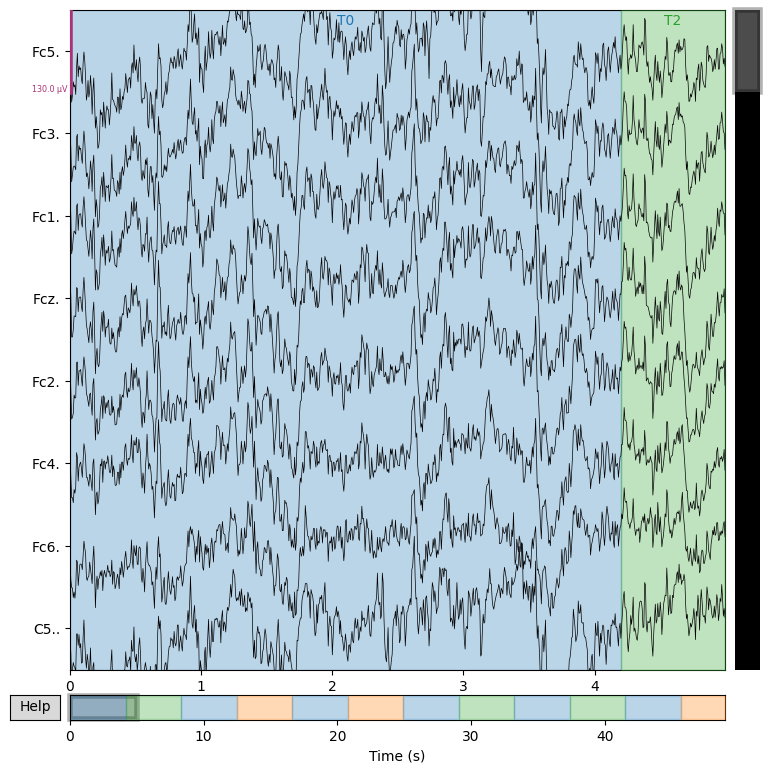

In [ ]:
# Plot the first few seconds of raw EEG.
# We display only 8 channels to keep the graph readable.

raw.plot(
    duration=5,
    n_channels=8,
    scalings="auto",
    title="BEFORE PREPROCESSING — Raw EEG"
)

plt.show()

In [ ]:
# Extract EEG samples as a NumPy array.
# Shape = (channels, samples)

data_raw = raw.get_data()

print("Raw EEG shape:", data_raw.shape)
print("Minimum value:", data_raw.min())
print("Maximum value:", data_raw.max())
print("Mean:", data_raw.mean())
print("Standard deviation:", data_raw.std())

Raw EEG shape: (64, 7840)
Minimum value: -0.00035
Maximum value: 0.0005949999999999999
Mean: -2.1579101562499998e-06
Standard deviation: 5.475614429649561e-05


In [ ]:
# Make a copy so that we can compare BEFORE and AFTER.
raw_resampled = raw.copy()

print("BEFORE resampling:")
print("Sampling frequency:", raw_resampled.info["sfreq"], "Hz")

# Resample to 120 Hz, following the target sampling rate used in the paper.
raw_resampled.resample(120, npad="auto", verbose=False)

print("\nAFTER resampling:")
print("Sampling frequency:", raw_resampled.info["sfreq"], "Hz")
print("Number of samples:", raw_resampled.n_times)

BEFORE resampling:
Sampling frequency: 160.0 Hz

AFTER resampling:
Sampling frequency: 120.0 Hz
Number of samples: 5880


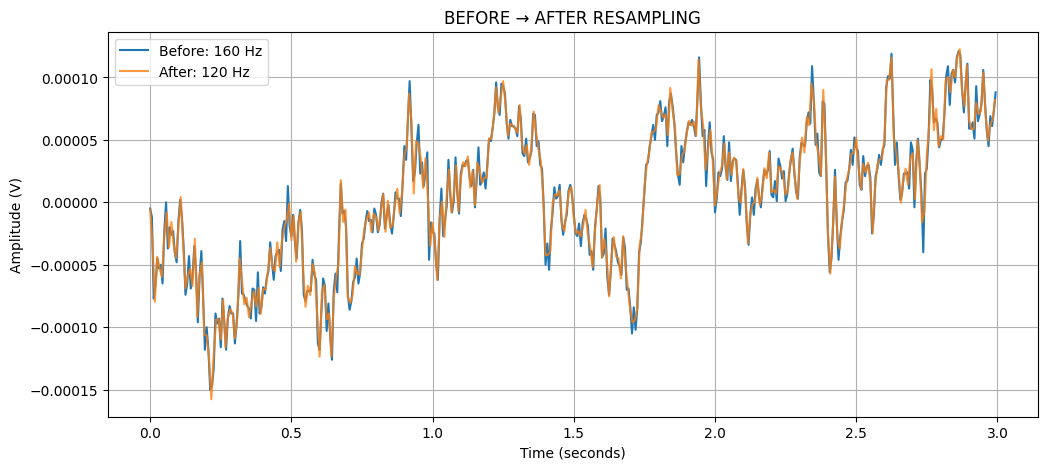

In [ ]:
# Select one channel for an easy visual comparison
channel_index = 0

# First 3 seconds
before_signal = raw.get_data(
    picks=[channel_index],
    start=0,
    stop=int(3 * raw.info["sfreq"])
).flatten()

after_signal = raw_resampled.get_data(
    picks=[channel_index],
    start=0,
    stop=int(3 * raw_resampled.info["sfreq"])
).flatten()

# Create time axes
time_before = np.arange(len(before_signal)) / raw.info["sfreq"]
time_after = np.arange(len(after_signal)) / raw_resampled.info["sfreq"]

plt.figure(figsize=(12, 5))

plt.plot(
    time_before,
    before_signal,
    label="Before: 160 Hz"
)

plt.plot(
    time_after,
    after_signal,
    label="After: 120 Hz",
    alpha=0.8
)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (V)")
plt.title("BEFORE → AFTER RESAMPLING")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Copy the resampled data
raw_bandpass = raw_resampled.copy()

print("BEFORE band-pass filtering")
print("Sampling frequency:", raw_bandpass.info["sfreq"])

# Apply the sixth-order Butterworth band-pass filter specified by the paper.
raw_bandpass.filter(
    l_freq=1.0,
    h_freq=15.0,
    method="iir",
    iir_params=dict(
        order=6,
        ftype="butter"
    ),
    verbose=False
)

print("AFTER band-pass filtering")
print("Frequency range retained: 1–15 Hz")
print("Filter type: 6th-order Butterworth")

BEFORE band-pass filtering
Sampling frequency: 120.0
AFTER band-pass filtering
Frequency range retained: 1–15 Hz
Filter type: 6th-order Butterworth


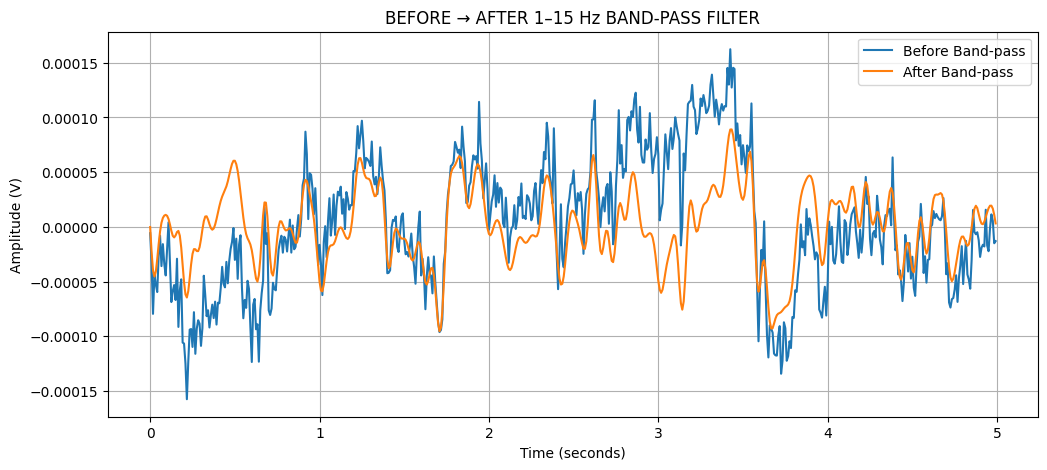

In [ ]:
# Select one channel
before = raw_resampled.get_data(
    picks=[channel_index],
    start=0,
    stop=int(5 * raw_resampled.info["sfreq"])
).flatten()

after = raw_bandpass.get_data(
    picks=[channel_index],
    start=0,
    stop=int(5 * raw_bandpass.info["sfreq"])
).flatten()

time = np.arange(len(before)) / raw_resampled.info["sfreq"]

plt.figure(figsize=(12, 5))

plt.plot(time, before, label="Before Band-pass")
plt.plot(time, after, label="After Band-pass")

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (V)")
plt.title("BEFORE → AFTER 1–15 Hz BAND-PASS FILTER")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Copy the band-pass filtered EEG
raw_notch = raw_bandpass.copy()

# Practical implementation choice:
# 50 Hz is used for power-line interference in this setup.
notch_frequency = 50.0

print("Applying notch filter at:", notch_frequency, "Hz")

raw_notch.notch_filter(
    freqs=[notch_frequency],
    verbose=False
)

print("Notch filtering completed.")

Applying notch filter at: 50.0 Hz
Notch filtering completed.


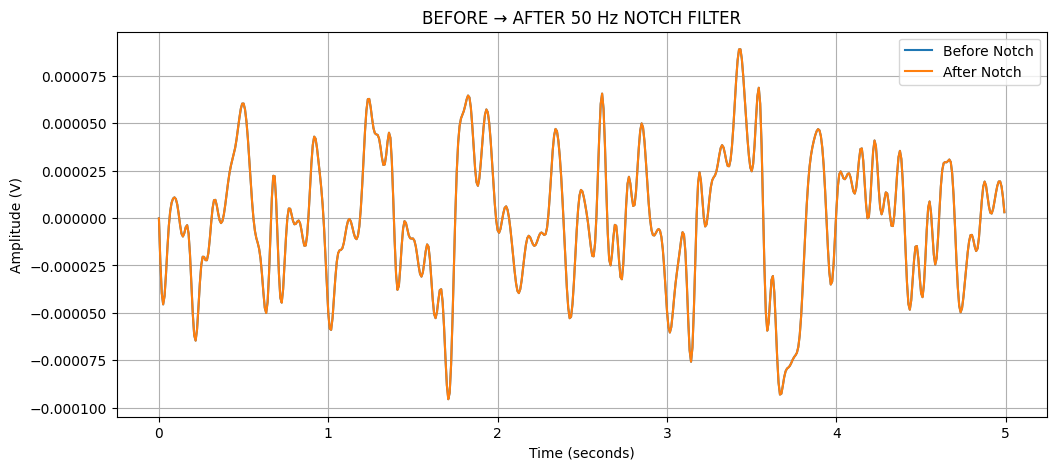

In [ ]:
before = raw_bandpass.get_data(
    picks=[channel_index],
    start=0,
    stop=int(5 * raw_bandpass.info["sfreq"])
).flatten()

after = raw_notch.get_data(
    picks=[channel_index],
    start=0,
    stop=int(5 * raw_notch.info["sfreq"])
).flatten()

time = np.arange(len(before)) / raw_bandpass.info["sfreq"]

plt.figure(figsize=(12, 5))

plt.plot(time, before, label="Before Notch")
plt.plot(time, after, label="After Notch")

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (V)")
plt.title("BEFORE → AFTER 50 Hz NOTCH FILTER")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Get filtered EEG data
data_before_winsor = raw_notch.get_data()

# Calculate lower and upper limits independently for every channel.
lower_limits = np.percentile(
    data_before_winsor,
    1,
    axis=1,
    keepdims=True
)

upper_limits = np.percentile(
    data_before_winsor,
    99,
    axis=1,
    keepdims=True
)

# Clip extreme values to the percentile boundaries.
data_winsor = np.clip(
    data_before_winsor,
    lower_limits,
    upper_limits
)

print("BEFORE Winsorisation")
print("Minimum:", data_before_winsor.min())
print("Maximum:", data_before_winsor.max())

print("\nAFTER Winsorisation")
print("Minimum:", data_winsor.min())
print("Maximum:", data_winsor.max())

BEFORE Winsorisation
Minimum: -0.00022932981772311861
Maximum: 0.0005017571654166224

AFTER Winsorisation
Minimum: -0.00012306147722677244
Maximum: 0.00015068676937904805


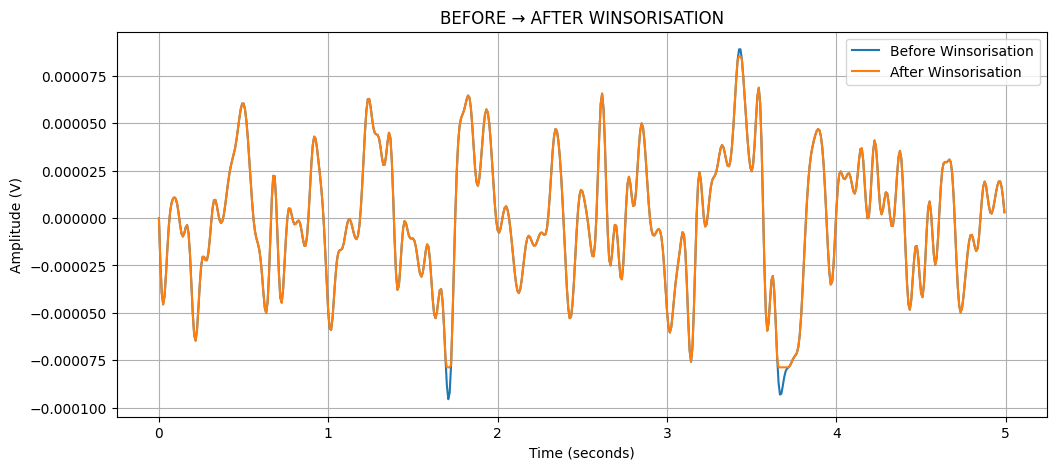

In [ ]:
# Compare one EEG channel
channel_data_before = data_before_winsor[channel_index]
channel_data_after = data_winsor[channel_index]

# Show first 5 seconds
n_plot = int(5 * raw_notch.info["sfreq"])

time = np.arange(n_plot) / raw_notch.info["sfreq"]

plt.figure(figsize=(12, 5))

plt.plot(
    time,
    channel_data_before[:n_plot],
    label="Before Winsorisation"
)

plt.plot(
    time,
    channel_data_after[:n_plot],
    label="After Winsorisation"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (V)")
plt.title("BEFORE → AFTER WINSORISATION")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Detect values outside the winsorisation boundaries
outlier_mask = (
    (data_before_winsor < lower_limits) |
    (data_before_winsor > upper_limits)
)

outlier_count = np.sum(outlier_mask)

total_values = data_before_winsor.size

outlier_percentage = (
    outlier_count / total_values
) * 100

print("========== OUTLIER ANALYSIS ==========")
print("Total values:", total_values)
print("Detected outliers:", outlier_count)
print("Outlier percentage:", outlier_percentage, "%")

========== OUTLIER ANALYSIS ==========
Total values: 376320
Detected outliers: 7552
Outlier percentage: 2.0068027210884356 %


In [ ]:
# Copy the notch-filtered Raw object
raw_clean = raw_notch.copy()

# Replace the signal with winsorised data
raw_clean._data = data_winsor

print("Clean EEG shape:", raw_clean.get_data().shape)
print("Sampling frequency:", raw_clean.info["sfreq"], "Hz")

Clean EEG shape: (64, 5880)
Sampling frequency: 120.0 Hz


In [ ]:
# Convert annotations into MNE events
events, event_id = mne.events_from_annotations(
    raw_clean,
    verbose=False
)

print("Event mapping:")
print(event_id)

print("\nFirst events:")
print(events[:10])

Event mapping:
{'T0': 1, 'T1': 2, 'T2': 3}

First events:
[[   0    0    1]
 [ 504    0    3]
 [ 996    0    1]
 [1500    0    2]
 [1992    0    1]
 [2496    0    2]
 [2988    0    1]
 [3492    0    3]
 [3984    0    1]
 [4488    0    3]]


In [ ]:
# We use only T1 and T2 for binary classification.
selected_events = events[
    np.isin(events[:, 2], [event_id["T1"], event_id["T2"]])
]

print("Number of T1/T2 events:", len(selected_events))

# Create 1-second windows.
window_start = 0.0
window_duration = 1.0

sfreq = raw_clean.info["sfreq"]

samples_per_window = int(window_duration * sfreq)

epochs_data = []
labels = []

for event in selected_events:

    event_sample = event[0]

    start_sample = event_sample + int(window_start * sfreq)
    end_sample = start_sample + samples_per_window

    # Make sure the window is inside the recording
    if end_sample <= raw_clean.n_times:

        segment = raw_clean.get_data(
            start=start_sample,
            stop=end_sample
        )

        epochs_data.append(segment)

        # Convert event ID to class label
        if event[2] == event_id["T1"]:
            labels.append("T1")
        else:
            labels.append("T2")

epochs_data = np.array(epochs_data)
labels = np.array(labels)

print("Epoch data shape:", epochs_data.shape)
print("Labels shape:", labels.shape)
print("Labels:", labels)

Number of T1/T2 events: 6
Epoch data shape: (6, 64, 120)
Labels shape: (6,)
Labels: ['T2' 'T1' 'T1' 'T2' 'T2' 'T1']


In [ ]:
# Show variables currently available in Colab
%whos

Variable                Type        Data/Info
---------------------------------------------
LabelEncoder            type        <class 'sklearn.preproces<...>ing._label.LabelEncoder'>
Model                   type        <class 'keras.src.models.model.Model'>
accuracy_score          function    <function accuracy_score at 0x7ba615678680>
after                   ndarray     600: 600 elems, type `float64`, 4800 bytes
after_signal            ndarray     360: 360 elems, type `float64`, 2880 bytes
annotation_counts       Series      T0    6\nT2    3\nT1    3<...>Name: count, dtype: int64
before                  ndarray     600: 600 elems, type `float64`, 4800 bytes
before_signal           ndarray     480: 480 elems, type `float64`, 3840 bytes
channel_data_after      ndarray     5880: 5880 elems, type `float64`, 47040 bytes
channel_data_before     ndarray     5880: 5880 elems, type `float64`, 47040 bytes
channel_index           int         0
classification_report   function    <function class

In [ ]:
import numpy as np
# epochs_data = epochs.get_data() # This line is removed as epochs_data is already defined from the previous cell

print("Epochs data shape:", epochs_data.shape)
# Peak-to-peak amplitude for every channel in every epoch
# Shape: (epochs, channels)

epoch_ptp = np.ptp(epochs_data, axis=2)

# Calculate a data-driven artifact threshold.
# We use the 99th percentile of channel peak-to-peak values.
artifact_threshold = np.percentile(epoch_ptp, 99)

print("Artifact threshold:", artifact_threshold)

# Mark epochs containing unusually large signal excursions
artifact_mask = np.any(
    epoch_ptp > artifact_threshold,
    axis=1
)
# The line below is redundant as epochs_data is already defined above
# epochs_data = epochs.get_data()

print("Epochs data shape:", epochs_data.shape)

print("Number of artifact-containing epochs:", artifact_mask.sum())
print("Total epochs:", len(epochs_data))

Epochs data shape: (6, 64, 120)
Artifact threshold: 0.0002495510763612079
Epochs data shape: (6, 64, 120)
Number of artifact-containing epochs: 2
Total epochs: 6


In [ ]:
print("epochs_data" in globals())

True


In [ ]:
# Remove epochs that were detected as artifacts

clean_epochs_data = epochs_data[~artifact_mask]

print("Original number of epochs:", len(epochs_data))
print("Number of artifact epochs removed:", artifact_mask.sum())
print("Number of clean epochs:", len(clean_epochs_data))

Original number of epochs: 6
Number of artifact epochs removed: 2
Number of clean epochs: 4
